# Symbol Correlation Matrix

Pairwise Pearson correlation of daily log returns across all 193 symbols (188 equities + 5 ETFs), 2021-2026.

Adds Lopez de Prado's Marchenko-Pastur denoising and market-mode detoning to separate signal from noise and reveal non-market structure.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from theta.analysis.correlation import (
    load_returns_wide,
    compute_correlation,
    cluster_order,
    summary_stats,
    denoise_correlation,
    detone_correlation,
    ETFS,
)
from theta.analysis.correlation.correlation import _mp_pdf

plt.rcParams["figure.dpi"] = 110

## 1. Load returns and compute raw correlation

In [2]:
wide, symbols = load_returns_wide(underlying_dir=Path.cwd().parent / "data" / "raw" / "underlying")
T = wide.height
print(f"Symbols: {len(symbols)}, Dates: {T}, Range: {wide['date'].min()} -> {wide['date'].max()}")

corr, kept = compute_correlation(wide, symbols, min_pairwise=252)
N = len(kept)
q = N / T
print(f"Correlation matrix: {corr.shape}, q = N/T = {q:.4f}")
dropped = set(symbols) - set(kept)
if dropped:
    print(f"Dropped: {sorted(dropped)}")

Symbols: 193, Dates: 1308, Range: 2021-01-05 -> 2026-03-20


Correlation matrix: (193, 193), q = N/T = 0.1476


## 2. Summary statistics (raw)

In [3]:
stats = summary_stats(corr, kept, top_k=10)
print(f"Pairs: {stats['n_pairs']:,}  mean: {stats['mean']:+.3f}  median: {stats['median']:+.3f}")
print(f"Range: [{stats['min']:+.3f}, {stats['max']:+.3f}]   IQR: [{stats['q25']:+.3f}, {stats['q75']:+.3f}]")
print("\nTop-10 highest:")
for a, b, c in stats["highest"]:
    print(f"  {a:6s} x {b:6s}  {c:+.3f}")
print("\nTop-10 lowest:")
for a, b, c in stats["lowest"]:
    print(f"  {a:6s} x {b:6s}  {c:+.3f}")

Pairs: 18,528  mean: +0.235  median: +0.231
Range: [-0.174, +0.903]   IQR: [+0.135, +0.328]

Top-10 highest:
  QQQ    x SPY     +0.903
  MA     x V       +0.864
  AMAT   x KLAC    +0.861
  AMAT   x LRCX    +0.834
  COP    x EOG     +0.810
  DUK    x SO      +0.806
  COP    x CVX     +0.806
  CDNS   x SNPS    +0.803
  HD     x LOW     +0.797
  GS     x MS      +0.797

Top-10 lowest:
  EOG    x TLT     -0.174
  SLB    x TLT     -0.166
  COP    x TLT     -0.154
  PSX    x TLT     -0.150
  AIG    x TLT     -0.150
  TLT    x XOM     -0.149
  CL     x PLTR    -0.139
  TLT    x WFC     -0.137
  MET    x TLT     -0.137
  SCHW   x TLT     -0.135


## 3. Distribution of pairwise correlations (raw)

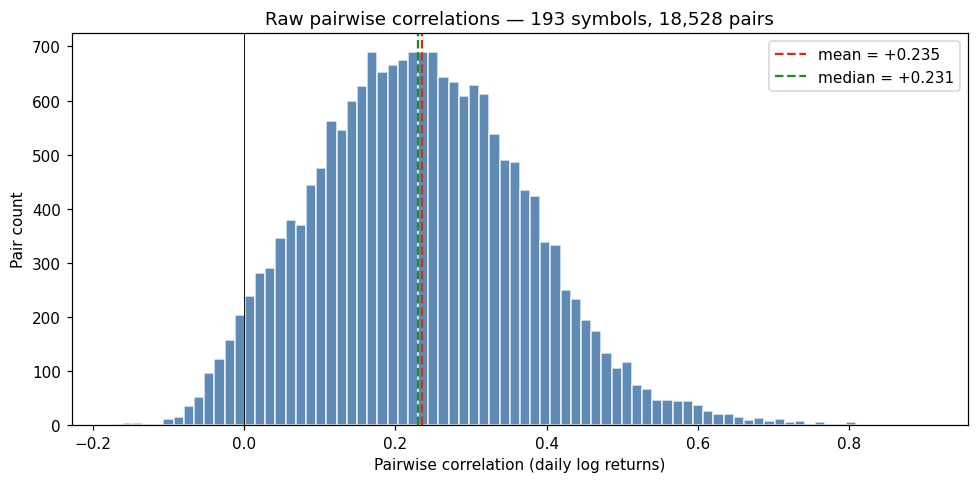

In [4]:
iu = np.triu_indices_from(corr, k=1)
off = corr[iu]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(off, bins=80, color="#4477AA", edgecolor="white", alpha=0.85)
ax.axvline(off.mean(), color="#CC3311", linestyle="--", label=f"mean = {off.mean():+.3f}")
ax.axvline(np.median(off), color="#228833", linestyle="--", label=f"median = {np.median(off):+.3f}")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Pairwise correlation (daily log returns)")
ax.set_ylabel("Pair count")
ax.set_title(f"Raw pairwise correlations — {len(kept)} symbols, {len(off):,} pairs")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Marchenko-Pastur denoising

For a random matrix of $T$ observations $\times$ $N$ variables, eigenvalues of the correlation matrix fall in $[\lambda_-, \lambda_+]$ where $\lambda_\pm = \sigma^2 (1 \pm \sqrt{N/T})^2$.

Empirical eigenvalues above $\lambda_+$ carry signal; those below are statistically noise.

**Constant residual denoising** flattens the noise bulk to its mean, preserving the signal eigenstructure.

In [5]:
corr_denoised, info = denoise_correlation(corr, q)
eigvals = info["eigvals"]
lam_plus = info["lam_plus"]
n_signal = info["n_signal"]

print(f"Fitted MP variance: {info['var']:.4f}")
print(f"Noise ceiling lam_plus: {lam_plus:.4f}")
print(f"Signal eigenvalues: {n_signal} / {N}")
print(f"Market mode variance fraction: {eigvals[0] / eigvals.sum() * 100:.1f}%")
print(f"Top-10 eigenvalues: {eigvals[:10].round(2)}")

Fitted MP variance: 1.0000
Noise ceiling lam_plus: 1.9158
Signal eigenvalues: 11 / 193
Market mode variance fraction: 25.9%
Top-10 eigenvalues: [49.98 15.7   8.76  4.3   3.71  3.52  2.84  2.64  2.44  2.05]


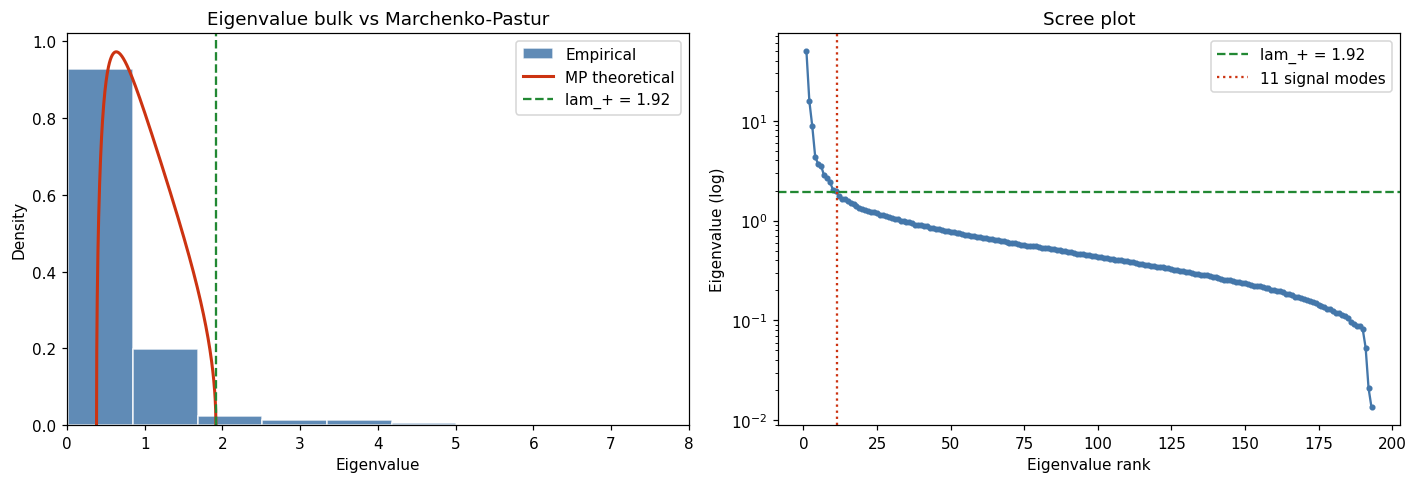

In [6]:
# Plot eigenvalue spectrum vs MP theoretical PDF
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(eigvals, bins=60, density=True, color="#4477AA", edgecolor="white", alpha=0.85, label="Empirical")
lam_grid, pdf_th = _mp_pdf(info["var"], q, pts=500)
ax.plot(lam_grid, pdf_th, color="#CC3311", linewidth=2, label="MP theoretical")
ax.axvline(lam_plus, color="#228833", linestyle="--", label=f"lam_+ = {lam_plus:.2f}")
ax.set_xlim(0, min(8, eigvals.max()))
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Density")
ax.set_title("Eigenvalue bulk vs Marchenko-Pastur")
ax.legend()

ax = axes[1]
ax.plot(range(1, N+1), eigvals, marker="o", markersize=3, color="#4477AA")
ax.axhline(lam_plus, color="#228833", linestyle="--", label=f"lam_+ = {lam_plus:.2f}")
ax.axvline(n_signal + 0.5, color="#CC3311", linestyle=":", label=f"{n_signal} signal modes")
ax.set_yscale("log")
ax.set_xlabel("Eigenvalue rank")
ax.set_ylabel("Eigenvalue (log)")
ax.set_title("Scree plot")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Detoning — remove the market mode

Subtract the top eigenpair (largest eigenvalue + associated eigenvector = the market component) from the denoised matrix. Result is singular by construction — **use for clustering/visualization only, not portfolio optimization.**

In [7]:
corr_detoned, info_d = detone_correlation(corr_denoised, n_market=1)
print(f"Market mode removed: {info_d['market_variance_fraction']*100:.1f}% of total variance")

iu = np.triu_indices_from(corr, k=1)
print(f"\n{'Matrix':<10} {'Mean':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
for name, M in [("raw", corr), ("denoised", corr_denoised), ("detoned", corr_detoned)]:
    off = M[iu]
    print(f"{name:<10} {off.mean():+8.3f} {np.median(off):+8.3f} {off.min():+8.3f} {off.max():+8.3f}")

Market mode removed: 25.2% of total variance

Matrix         Mean   Median      Min      Max
raw          +0.235   +0.231   -0.174   +0.903
denoised     +0.233   +0.238   -0.168   +0.578
detoned      -0.003   -0.018   -0.288   +0.527


## 6. Three-panel heatmap comparison

All three matrices rendered in **the same clustering order** (computed from the detoned matrix, since that's where sector structure is cleanest).

- **Raw:** dominated by red — everything correlated with everything via market mode.
- **Denoised:** same structure, cleaner blocks, better-conditioned for inversion.
- **Detoned:** market subtracted, revealing sector/factor blocks as off-diagonal clusters.

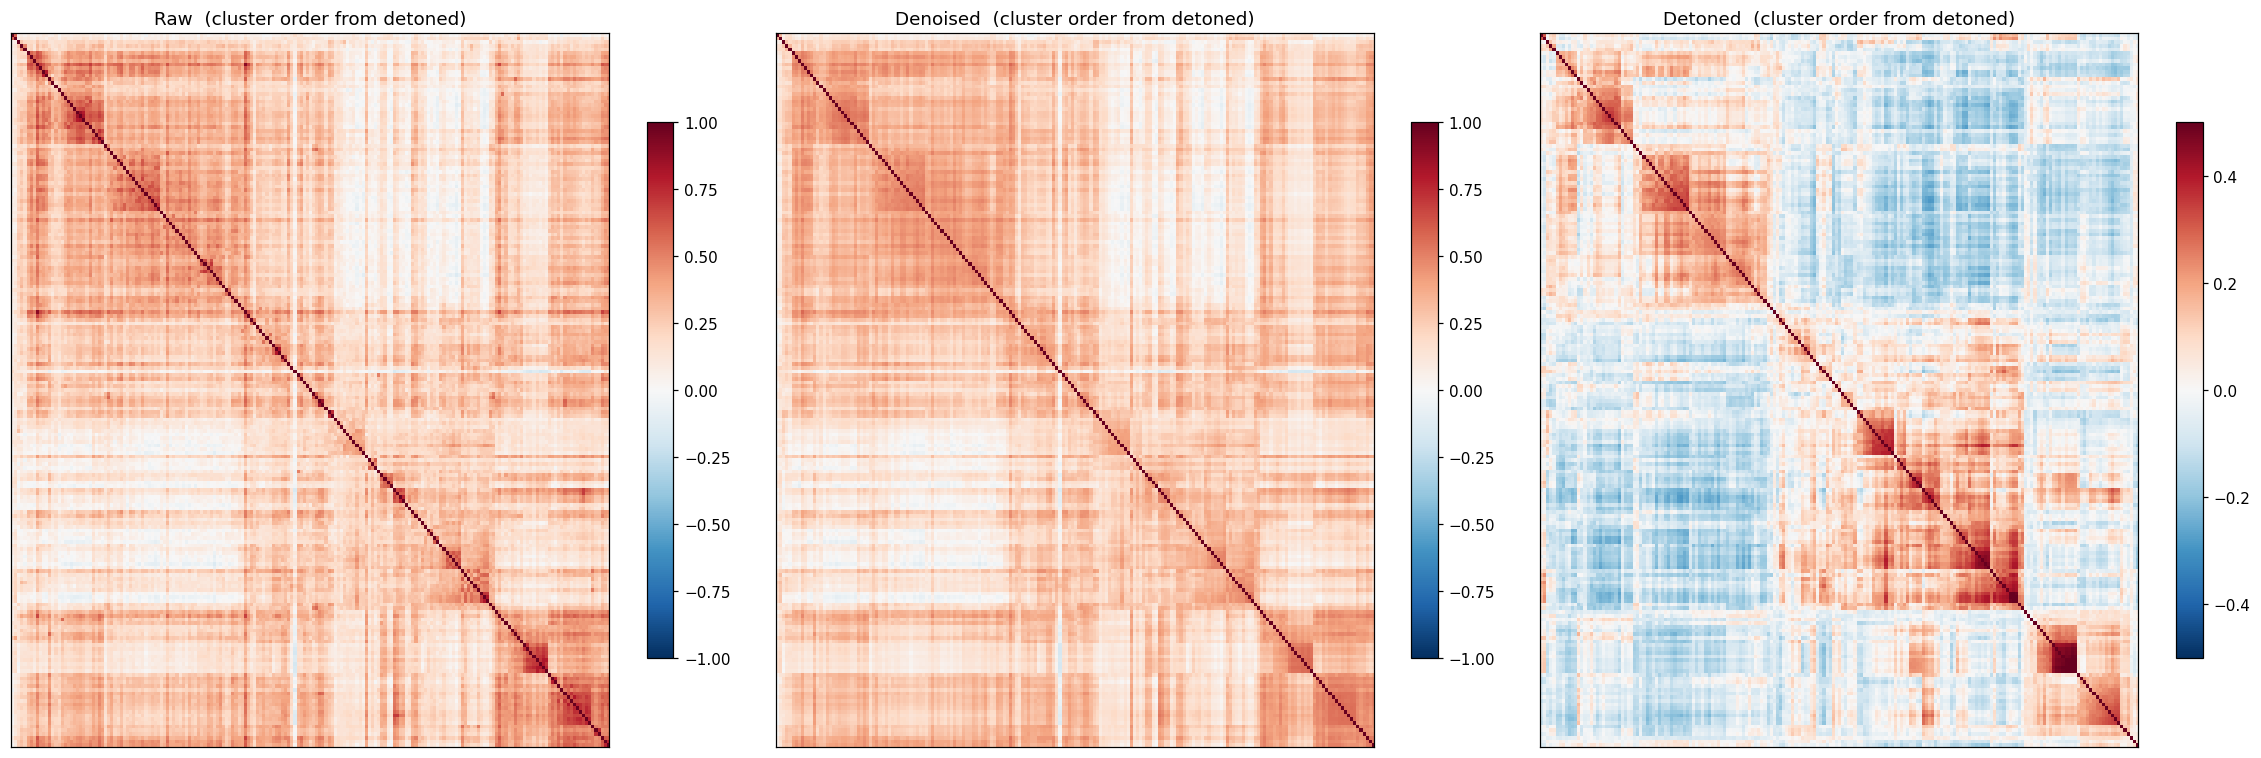

In [8]:
order = cluster_order(corr_detoned, method="average")
labels_ord = [kept[i] for i in order]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, (title, M, vmin, vmax) in zip(
    axes,
    [("Raw", corr, -1, 1), ("Denoised", corr_denoised, -1, 1), ("Detoned", corr_detoned, -0.5, 0.5)],
):
    M_ord = M[np.ix_(order, order)]
    im = ax.imshow(M_ord, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(f"{title}  (cluster order from detoned)")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()
plt.show()

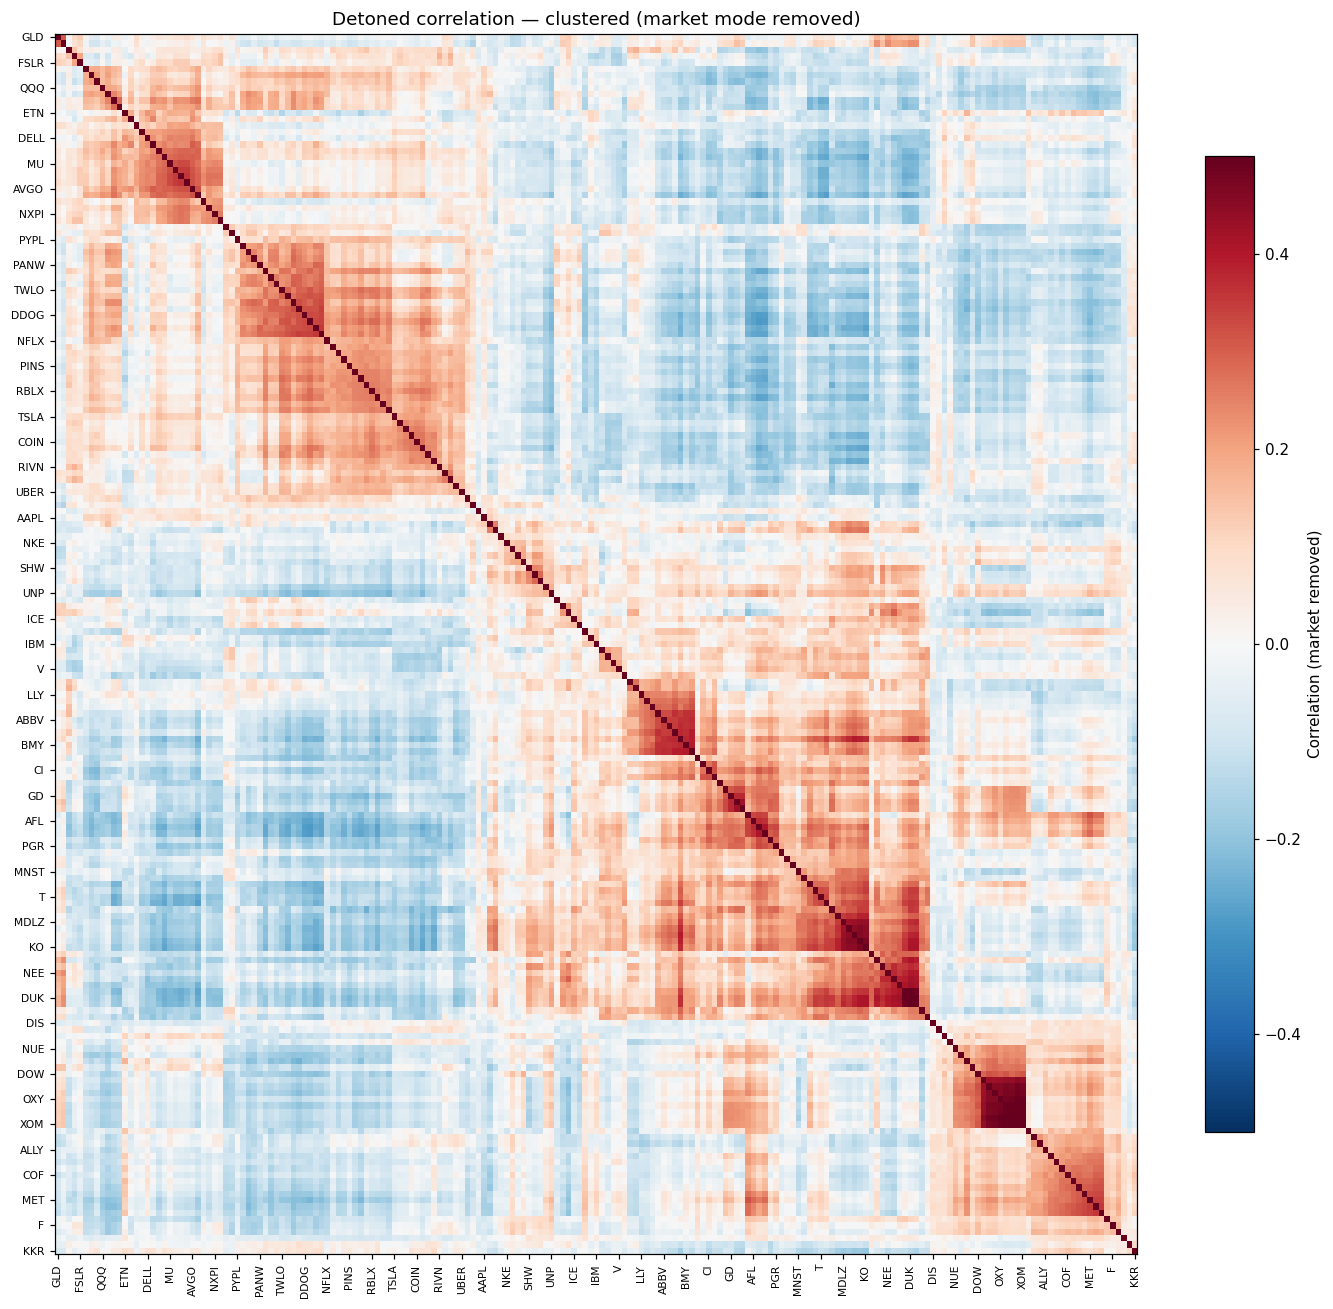

In [9]:
# Full-size clustered heatmap of the detoned matrix with readable tick labels
M_ord = corr_detoned[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(13, 12))
im = ax.imshow(M_ord, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
ax.set_title("Detoned correlation — clustered (market mode removed)")
step = max(1, len(labels_ord) // 48)
ticks = list(range(0, len(labels_ord), step))
ax.set_xticks(ticks)
ax.set_xticklabels([labels_ord[i] for i in ticks], rotation=90, fontsize=7)
ax.set_yticks(ticks)
ax.set_yticklabels([labels_ord[i] for i in ticks], fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlation (market removed)")
plt.tight_layout()
plt.show()

## 7. Sector-like clusters revealed by detoning

The detoned matrix's strongest off-diagonal clusters are non-market co-movements — industry / factor groupings. Report the top pairs.

In [10]:
stats_det = summary_stats(corr_detoned, kept, top_k=20)
print("Top-20 highest detoned correlations (pure sector/factor signal):")
for a, b, c in stats_det["highest"]:
    print(f"  {a:6s} x {b:6s}  {c:+.3f}")
print("\nTop-20 most negative detoned correlations:")
for a, b, c in stats_det["lowest"]:
    print(f"  {a:6s} x {b:6s}  {c:+.3f}")

Top-20 highest detoned correlations (pure sector/factor signal):
  DUK    x SO      +0.527
  COP    x XOM     +0.516
  COP    x EOG     +0.514
  COP    x CVX     +0.507
  EOG    x XOM     +0.505
  CVX    x XOM     +0.504
  D      x DUK     +0.501
  COP    x OXY     +0.496
  CVX    x EOG     +0.495
  OXY    x XOM     +0.489
  D      x SO      +0.486
  COP    x SLB     +0.485
  EOG    x OXY     +0.484
  COP    x PSX     +0.483
  CVX    x OXY     +0.478
  SLB    x XOM     +0.477
  PSX    x XOM     +0.475
  CVX    x SLB     +0.473
  CL     x KO      +0.472
  EOG    x SLB     +0.472

Top-20 most negative detoned correlations:
  CB     x NET     -0.288
  NET    x TRV     -0.285
  CB     x DDOG    -0.278
  DDOG   x TRV     -0.276
  NVDA   x VZ      -0.275
  CB     x SHOP    -0.269
  AFL    x NET     -0.269
  CRWD   x KO      -0.267
  AFL    x DDOG    -0.267
  KO     x PLTR    -0.264
  SHOP   x TRV     -0.264
  KO     x MRVL    -0.264
  CB     x ZS      -0.263
  TRV    x ZS      -0.263
  D    

## 8. ETF correlation profile (raw vs detoned)
How SPY / QQQ / IWM / GLD / TLT project onto the universe, before and after removing the market mode.

In [11]:
etf_list = [e for e in ["SPY", "QQQ", "IWM", "GLD", "TLT"] if e in kept]
equities = [s for s in kept if s not in ETFS]
eq_idx = [kept.index(s) for s in equities]

print(f"{'ETF':<6} {'raw mean':>10} {'detoned mean':>14} {'raw max':>10} {'detoned max':>14}")
for etf in etf_list:
    ei = kept.index(etf)
    r = corr[ei, eq_idx]
    d = corr_detoned[ei, eq_idx]
    print(f"{etf:<6} {r.mean():+10.3f} {d.mean():+14.3f} {r.max():+10.3f} {d.max():+14.3f}")

ETF      raw mean   detoned mean    raw max    detoned max
SPY        +0.420         -0.004     +0.680         +0.102
QQQ        +0.389         -0.015     +0.712         +0.223
IWM        +0.366         -0.008     +0.607         +0.099
GLD        +0.063         +0.004     +0.586         +0.307
TLT        +0.027         +0.001     +0.252         +0.297


## 9. Save artifacts

In [12]:
out_dir = Path.cwd().parent / "data" / "processed" / "correlation"
out_dir.mkdir(parents=True, exist_ok=True)
np.save(out_dir / "corr_raw.npy", corr)
np.save(out_dir / "corr_denoised.npy", corr_denoised)
np.save(out_dir / "corr_detoned.npy", corr_detoned)
np.save(out_dir / "eigvals_raw.npy", info["eigvals"])
with open(out_dir / "symbols.txt", "w") as f:
    f.write("\n".join(kept))
with open(out_dir / "denoise_info.txt", "w") as f:
    f.write(f"N={N}\nT={T}\nq={q:.6f}\nvar={info['var']:.6f}\nlam_plus={info['lam_plus']:.6f}\nn_signal={info['n_signal']}\nmarket_variance_fraction={info_d['market_variance_fraction']:.6f}\n")
print(f"Saved to {out_dir}")

Saved to E:\Theta\data\processed\correlation
